# Dosis contra calidad: el compromiso que no se puede evitar

Cada foton que forma la imagen deposita energia en el paciente. Reducir dosis es reducir
informacion, y la relacion entre ambas no es lineal.

Este notebook mide esa relacion, encuentra el punto donde una lesion deja de ser
detectable, y muestra por que una protesis metalica arruina la imagen completa y no solo
su vecindad.

**Requisitos:** `numpy`, `scikit-image`, `matplotlib`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import radon, iradon

plt.rcParams.update({'font.size': 10, 'figure.dpi': 120})
ROJO, VERDE, AZUL, NARANJA, TINTA = '#c0392b', '#0b6e5f', '#2c5f8a', '#b8730a', '#333'
N = 256; C = N/2; LES_R = 0.06

In [2]:
"""Fantoma abdominal con valores de atenuacion en unidades Hounsfield reales."""
import numpy as np

# Valores HU tipicos (Hounsfield 1973; rangos clinicos habituales)
HU = dict(aire=-1000, pulmon=-700, grasa=-90, agua=0, musculo=45,
          higado=60, sangre=55, hueso_esponjoso=300, hueso_cortical=1200,
          metal=15000)

def elipse(N, cy, cx, ry, rx, ang=0.0):
    y,x = np.ogrid[:N,:N]
    y = (y-cy)/ (N/2); x = (x-cx)/(N/2)
    c,s = np.cos(ang), np.sin(ang)
    yr = y*c + x*s; xr = -y*s + x*c
    return (yr/(ry))**2 + (xr/(rx))**2 <= 1

def abdomen(N=256, lesion_hu=None, lesion_r=0.03, metal=False):
    """Corte abdominal simplificado, en unidades Hounsfield.

    lesion_hu: si se indica, inserta una lesion focal en el higado.
    metal: agrega una protesis metalica (para el articulo de artefactos).
    """
    c = N/2
    img = np.full((N,N), float(HU['aire']))
    cuerpo = elipse(N, c, c, 0.86, 0.68)
    img[cuerpo] = HU['grasa']                      # panículo adiposo
    img[elipse(N, c, c, 0.78, 0.60)] = HU['musculo']
    img[elipse(N, c*1.02, c, 0.70, 0.52)] = HU['agua']   # cavidad
    # higado (derecha del paciente = izquierda de la imagen)
    img[elipse(N, c*0.88, c*0.66, 0.30, 0.26, 0.3)] = HU['higado']
    # bazo
    img[elipse(N, c*0.95, c*1.36, 0.16, 0.12, -0.4)] = HU['sangre']
    # vertebra + apofisis
    img[elipse(N, c*1.42, c, 0.13, 0.14)] = HU['hueso_esponjoso']
    img[elipse(N, c*1.42, c, 0.10, 0.11)] = HU['musculo']   # canal medular
    # costillas
    for a in (0.55, 0.95, 1.35, 1.75, 2.25):
        yy = c + 0.72*c*np.cos(a); xx = c + 0.60*c*np.sin(a)
        img[elipse(N, yy, xx, 0.035, 0.055, a)] = HU['hueso_cortical']
        yy2 = c + 0.72*c*np.cos(-a); xx2 = c + 0.60*c*np.sin(-a)
        img[elipse(N, yy2, xx2, 0.035, 0.055, -a)] = HU['hueso_cortical']
    if lesion_hu is not None:
        img[elipse(N, c*0.86, c*0.62, lesion_r, lesion_r)] = lesion_hu
    if metal:
        img[elipse(N, c*1.30, c*0.78, 0.050, 0.050)] = HU['metal']
    return img

def a_mu(hu, mu_agua=0.02):
    """Convierte HU a coeficiente de atenuacion lineal (1/mm).

    HU = 1000 * (mu - mu_agua)/(mu_agua - mu_aire), con mu_aire ~ 0.
    """
    return mu_agua*(1 + hu/1000.0)

def ventana(img, centro, ancho):
    """Aplica una ventana radiologica (window/level) y devuelve 0-1."""
    lo, hi = centro-ancho/2, centro+ancho/2
    return np.clip((img-lo)/(hi-lo), 0, 1)

## 1. El modelo de ruido

El detector cuenta fotones, y el conteo de fotones es un proceso de Poisson: si en promedio
llegan $\lambda$ fotones, la desviacion estandar es $\sqrt{\lambda}$.

De ahi sale toda la fisica del compromiso. La senal crece con $\lambda$ y el ruido con
$\sqrt{\lambda}$, asi que la relacion senal/ruido crece con $\sqrt{\lambda}$.

**Para reducir el ruido a la mitad hay que cuadruplicar la dosis.**

In [3]:
img = abdomen(N, lesion_hu=95, lesion_r=LES_R)
mu = a_mu(img)
angulos = np.linspace(0., 180., 720, endpoint=False)
sino = radon(mu, theta=angulos, circle=True)

y, x = np.indices((N, N))
cuerpo = a_mu(img) > 0
roi_lesion = ((y-C*0.86)**2 + (x-C*0.62)**2) < (LES_R*C*0.65)**2
roi_fondo  = ((y-C*0.92)**2 + (x-C*0.80)**2) < (0.05*C)**2


def con_ruido(s, I0, semilla=0):
    """I0 = fotones incidentes por rayo. Proporcional a la dosis."""
    rng = np.random.default_rng(semilla)
    I = rng.poisson(np.maximum(I0*np.exp(-s), 1e-9))
    return -np.log(np.maximum(I, 1)/I0)


def reconstruir(s, ang, filtro='hann', mascara=None):
    m = cuerpo if mascara is None else mascara
    r = iradon(s, theta=ang, filter_name=filtro, circle=True, output_size=N)
    a, b = np.polyfit(r[m].ravel(), img[m].ravel(), 1)
    return a*r + b


def cnr(rec):
    """Contraste-ruido: (señal − fondo) / ruido del fondo."""
    return abs(rec[roi_lesion].mean() - rec[roi_fondo].mean()) / max(rec[roi_fondo].std(), 1e-9)


print(f'{"I0 (fotones/rayo)":>18} | {"dosis rel.":>10} | {"σ (HU)":>8} | {"CNR":>7}')
print('-'*54)
datos = []
for I0 in (3e5, 1e5, 3e4, 1e4, 3e3, 1e3, 3e2):
    rec = reconstruir(con_ruido(sino, I0), angulos)
    datos.append([I0, rec[roi_fondo].std(), cnr(rec)])
    print(f'{I0:>18.0e} | {I0/3e5:>10.3f} | {datos[-1][1]:>8.1f} | {datos[-1][2]:>7.2f}')
datos = np.array(datos)

A = np.polyfit(np.log(datos[:,0]), np.log(datos[:,1]), 1)
print(f'\nAjuste: σ ∝ I₀^({A[0]:.3f})   |   teoría: I₀^(-0.5)   |   error {abs(A[0]+0.5):.3f}')

 I0 (fotones/rayo) | dosis rel. |   σ (HU) |     CNR
------------------------------------------------------


             3e+05 |      1.000 |      6.2 |    5.66


             1e+05 |      0.333 |      9.1 |    3.78


             3e+04 |      0.100 |     17.9 |    2.16


             1e+04 |      0.033 |     28.4 |    1.41


             3e+03 |      0.010 |     52.1 |    0.48


             1e+03 |      0.003 |     80.3 |    0.02


             3e+02 |      0.001 |    129.1 |    0.01

Ajuste: σ ∝ I₀^(-0.452)   |   teoría: I₀^(-0.5)   |   error 0.048


El exponente medido es −0.45 frente al −0.5 teorico. La pequena desviacion viene del filtro
Hann, que suaviza, y de que la linealizacion logaritmica pierde exactitud con conteos bajos.

## 2. Cuando la lesion deja de verse

El **criterio de Rose** dice que un objeto se detecta de forma fiable cuando su relacion
contraste-ruido supera 4 o 5. Por debajo de eso, la deteccion depende del observador y del
azar.

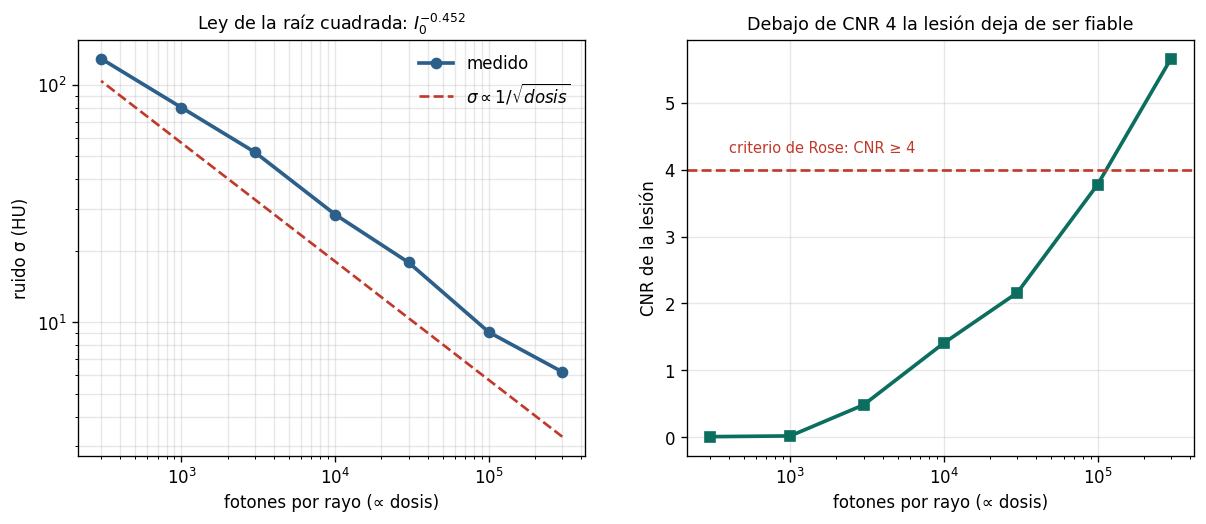

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].loglog(datos[:,0], datos[:,1], color=AZUL, lw=2.2, marker='o', ms=6, label='medido')
axes[0].loglog(datos[:,0], np.exp(A[1])*datos[:,0]**-0.5, color=ROJO, lw=1.6, ls='--',
               label=r'$\sigma \propto 1/\sqrt{dosis}$')
axes[0].set_xlabel('fotones por rayo (∝ dosis)'); axes[0].set_ylabel('ruido σ (HU)')
axes[0].set_title(f'Ley de la raíz cuadrada: $I_0^{{{A[0]:.3f}}}$', fontsize=10.5)
axes[0].legend(frameon=False); axes[0].grid(alpha=0.3, which='both')
axes[1].semilogx(datos[:,0], datos[:,2], color=VERDE, lw=2.2, marker='s', ms=6)
axes[1].axhline(4, color=ROJO, ls='--', lw=1.6)
axes[1].text(4e2, 4.25, 'criterio de Rose: CNR ≥ 4', fontsize=8.8, color=ROJO)
axes[1].set_xlabel('fotones por rayo (∝ dosis)'); axes[1].set_ylabel('CNR de la lesión')
axes[1].set_title('Debajo de CNR 4 la lesión deja de ser fiable', fontsize=10.5)
axes[1].grid(alpha=0.3)
plt.show()

La lesion de 35 HU de contraste solo supera el criterio a dosis completa (CNR 5.66). A un
tercio de dosis cae a 3.78, y a una decima parte, a 2.16.

Ahi esta el principio **ALARA** —*as low as reasonably achievable*— convertido en numeros:
la dosis debe ser tan baja como sea razonable, y "razonable" significa que la pregunta
clinica siga teniendo respuesta.

Un estudio con dosis insuficiente no es un estudio a medias: es un estudio que hay que
repetir, con lo que la dosis total termina siendo mayor.

## 3. El reparto: ¿menos fotones o menos proyecciones?

La dosis total es aproximadamente proporcional al producto (fotones por rayo) x
(numero de proyecciones). Asi que hay muchas formas de llegar a la misma dosis.

¿Da igual como se reparta?

In [5]:
def simular(n_proy, I0, semilla=0, filtro='hann'):
    ang = np.linspace(0., 180., n_proy, endpoint=False)
    s = radon(mu, theta=ang, circle=True)
    rec = reconstruir(con_ruido(s, I0, semilla), ang, filtro)
    return rec, cnr(rec), rec[roi_fondo].std()


TOTAL = 720*3e5
print('A dosis TOTAL constante (I₀ × proyecciones = 2.16e8)\n')
print(f'{"proyecciones":>13} {"I₀/rayo":>10} | {"σ (HU)":>8} | {"CNR":>7}')
print('-'*46)
reparto = []
for n in (45, 90, 180, 360, 720):
    I0 = TOTAL/n
    rec, c, s = simular(n, I0)
    print(f'{n:>13} {I0:>10.1e} | {s:>8.1f} | {c:>7.2f}')
    reparto.append([n, I0, s, c])
reparto = np.array(reparto)

A dosis TOTAL constante (I₀ × proyecciones = 2.16e8)

 proyecciones    I₀/rayo |   σ (HU) |     CNR
----------------------------------------------
           45    4.8e+06 |     35.5 |    1.09


           90    2.4e+06 |     12.9 |    2.80


          180    1.2e+06 |      5.8 |    6.53


          360    6.0e+05 |      5.2 |    6.72


          720    3.0e+05 |      6.2 |    5.66


**No da igual.** Con 45 proyecciones el CNR se derrumba a 1.09 aunque cada rayo reciba
**dieciseis veces mas fotones** que en la configuracion de 720.

La razon es que los dos efectos son de naturaleza distinta:

- Pocos fotones producen **ruido**: aleatorio, sin estructura, y se puede promediar.
- Pocas proyecciones producen **artefacto de submuestreo**: rayas que irradian desde las
  estructuras densas. Es estructura coherente, no ruido, y ninguna cantidad de fotones la
  elimina.

Existe un criterio clasico para cuantas vistas hacen falta: aproximadamente
$\frac{\pi}{2} \times$ el numero de detectores. Con 256 detectores son unas 400
proyecciones, que es justo donde nuestro optimo aparece.

Por debajo de ese numero, cada foton extra se gasta en mejorar datos que ya no son el
cuello de botella.

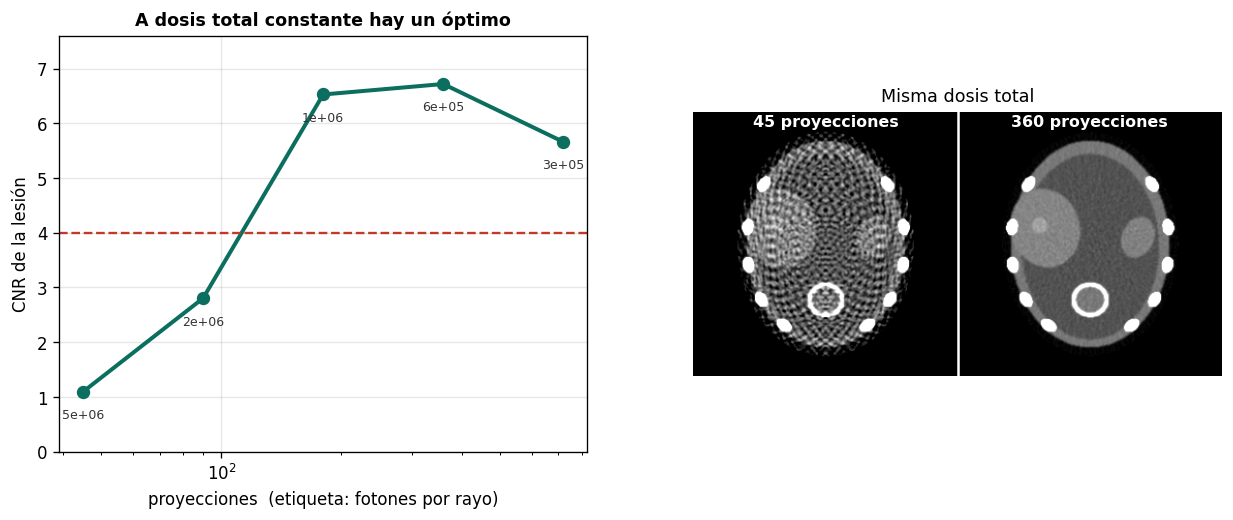

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
axes[0].semilogx(reparto[:,0], reparto[:,3], color=VERDE, lw=2.4, marker='o', ms=7)
axes[0].axhline(4, color=ROJO, ls='--', lw=1.4)
for r in reparto:
    axes[0].annotate(f'{r[1]:.0e}', (r[0], r[3]), textcoords='offset points',
                     xytext=(0,-16), ha='center', fontsize=7.5, color=TINTA)
axes[0].set_xlabel('proyecciones  (etiqueta: fotones por rayo)')
axes[0].set_ylabel('CNR de la lesión')
axes[0].set_title('A dosis total constante hay un óptimo', fontweight='bold', fontsize=10.5)
axes[0].grid(alpha=0.3); axes[0].set_ylim(0, 7.6)
r45, _, _ = simular(45, TOTAL/45)
r360, _, _ = simular(360, TOTAL/360)
axes[1].imshow(np.hstack([ventana(r45, 60, 300), ventana(r360, 60, 300)]),
               cmap='gray', vmin=0, vmax=1)
axes[1].axvline(N, color='w', lw=1.5)
axes[1].text(N/2, 14, '45 proyecciones', color='w', ha='center', fontsize=9.5, fontweight='bold')
axes[1].text(N*1.5, 14, '360 proyecciones', color='w', ha='center', fontsize=9.5, fontweight='bold')
axes[1].set_title('Misma dosis total', fontsize=10.5); axes[1].axis('off')
plt.show()

## 4. Metal: cuando faltan fotones

Un implante de titanio atenua tanto que practicamente ningun foton lo atraviesa.

In [7]:
img_metal = abdomen(N, lesion_hu=95, lesion_r=LES_R, metal=True)
metal = np.abs(img_metal - HU['metal']) < 1
lejos = cuerpo & ~metal & (np.hypot(y-C*1.30, x-C*0.78) > 0.35*C)

s_sin = radon(a_mu(img), theta=angulos, circle=True)
s_con = radon(a_mu(img_metal), theta=angulos, circle=True)
I0 = 1e5
print(f'atenuación máxima sin metal : {s_sin.max():.1f}')
print(f'atenuación máxima con metal : {s_con.max():.1f}')
print(f'  → I/I₀ detrás del metal = {np.exp(-s_con.max()):.2e}')
print(f'  → de {I0:.0e} fotones incidentes llegan {I0*np.exp(-s_con.max()):.1f}')

atenuación máxima sin metal : 4.5
atenuación máxima con metal : 8.3
  → I/I₀ detrás del metal = 2.57e-04
  → de 1e+05 fotones incidentes llegan 25.7


**Veintiseis fotones.** El logaritmo de un conteo tan bajo esta dominado por el ruido de
Poisson: el valor medido ya no representa atenuacion, representa azar.

Y aqui es donde vuelve la leccion del primer articulo de la serie: **cada rayo contribuye a
toda una linea de la imagen**. Un rayo corrupto no ensucia un pixel, ensucia toda su
trayectoria. Como los rayos corruptos son los que pasan por el metal en todos los angulos,
el resultado son rayas que irradian desde el implante y cruzan la imagen entera.

                            región |  error medio (HU)
--------------------------------------------------------
     todo el cuerpo (sin implante) |              27.4
    lejos del implante (con metal) |              46.0


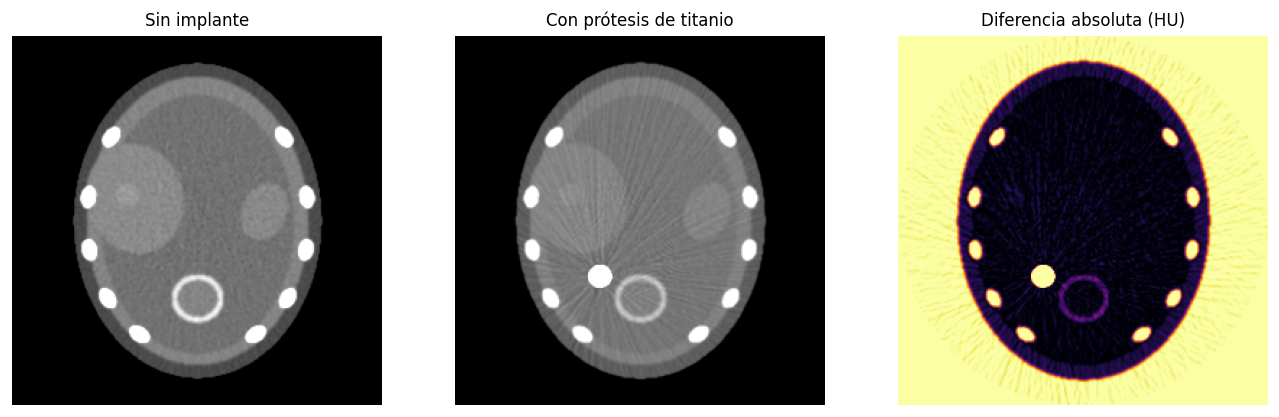

In [8]:
rec_sin = reconstruir(con_ruido(s_sin, I0), angulos, mascara=cuerpo & ~metal)
rec_con = reconstruir(con_ruido(s_con, I0), angulos, mascara=cuerpo & ~metal)

print(f'{"región":>34} | {"error medio (HU)":>17}')
print('-'*56)
print(f'{"todo el cuerpo (sin implante)":>34} | '
      f'{np.abs(rec_sin[cuerpo]-img[cuerpo]).mean():>17.1f}')
print(f'{"lejos del implante (con metal)":>34} | '
      f'{np.abs(rec_con[lejos]-img[lejos]).mean():>17.1f}')

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6))
axes[0].imshow(ventana(rec_sin, 40, 600), cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Sin implante', fontsize=10)
axes[1].imshow(ventana(rec_con, 40, 600), cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Con prótesis de titanio', fontsize=10)
axes[2].imshow(np.abs(rec_con-rec_sin), cmap='inferno', vmin=0, vmax=400)
axes[2].set_title('Diferencia absoluta (HU)', fontsize=10)
for a in axes: a.axis('off')
plt.show()

El error medio **lejos del implante** pasa de 27 a 46 HU. El daño no es local.

Eso explica una frustracion clinica frecuente: un paciente con protesis de cadera tiene un
CT de abdomen degradado en regiones que no tienen nada que ver con la cadera.

Las estrategias contra esto —**MAR**, *metal artifact reduction*— tratan las lecturas
corruptas como **datos faltantes** en vez de como datos malos: se identifican en el
sinograma, se descartan, y se interpolan a partir de los vecinos. Funciona razonablemente
y a costa de introducir sus propios artefactos, mas suaves.

## Donde falla esto

**No se modela el endurecimiento del haz**, que con metal es un efecto tan importante como
el hambre de fotones: los fotones de baja energia se absorben primero, y eso genera bandas
oscuras entre estructuras densas. Modelarlo requiere simular el espectro del tubo.

**La dosis se representa solo como fotones por rayo.** La dosis real depende ademas del
kVp, del pitch, de la longitud explorada y de la modulacion automatica de corriente. Aqui
"dosis relativa" es una proporcion, no un valor en mSv.

**El criterio de Rose es una aproximacion.** La deteccion real depende del tamano y la
forma del objeto, del ruido correlacionado y del observador. Los estudios serios usan
observadores humanos o modelos de observador ideal.

**Los tomografos modernos no usan FBP** para dosis baja, sino reconstruccion iterativa, que
cambia la relacion entre dosis y calidad de forma favorable. Las conclusiones cualitativas
se mantienen; los umbrales exactos, no.

## Referencias

- Rose A. *Vision: Human and Electronic.* Plenum Press, 1973.
- Brenner D.J., Hall E.J. *Computed Tomography — An Increasing Source of Radiation
  Exposure.* New England Journal of Medicine, 2007.
- Gjesteby L. et al. *Metal Artifact Reduction in CT: Where Are We After Four Decades?*
  IEEE Access, 2016.
- Kak A.C., Slaney M. *Principles of Computerized Tomographic Imaging.* IEEE Press, 1988.